In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from util.util import *

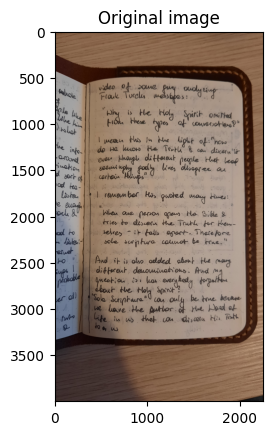

In [10]:
img_path = "sample7.jpg"
img_original = cv2.imread(img_path)
show(img_original, title="Original image")

show_images = True
figsize = (10,8)


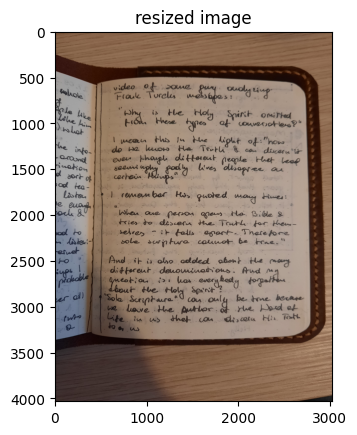

In [11]:
resize_image = False
if img_original.shape != (4032, 3024):
    resize_image = True
    img, scale_x, scale_y = resize_to_consistent_resolution(img_original, target_width=3024, target_height=4032)
    show(img, title="resized image")

gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
edges = find_edges(gray, kernel_size=5, binary_min_threshold=30)
# show(edges)

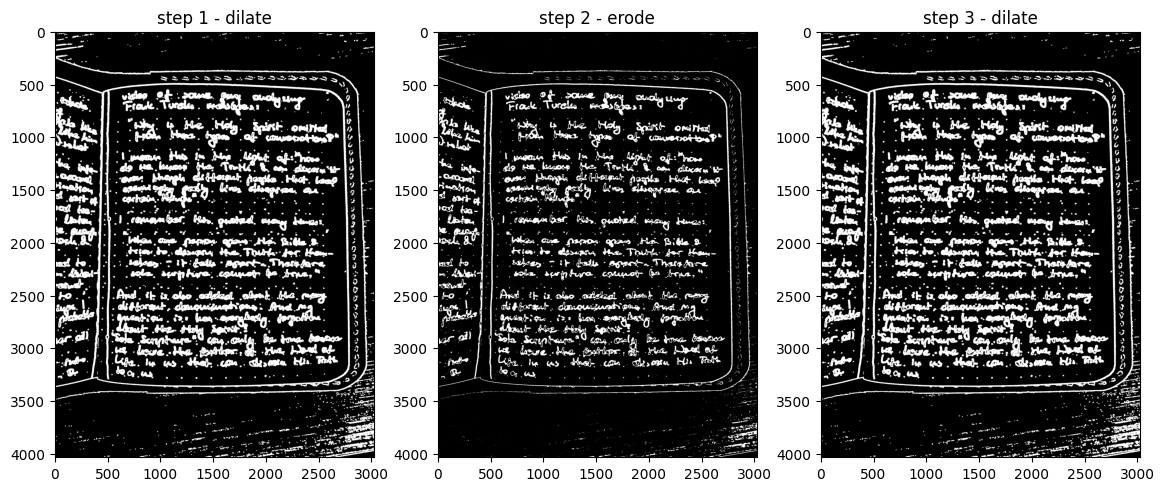

In [12]:
dilated = dilate(edges, kernel_size=7, iterations=1)
if show_images:
    plt.figure(figsize=(14,12))
    plt.subplot(1,3,1)
    show(dilated, title="step 1 - dilate")

eroded = erode(dilated, kernel_size=7, iterations=1)
if show_images:
    plt.subplot(1,3,2)
    show(eroded, title="step 2 - erode")

dilated = dilate(eroded, kernel_size=7, iterations=1)
if show_images:
    plt.subplot(1,3,3)
    show(dilated, title="step 3 - dilate")

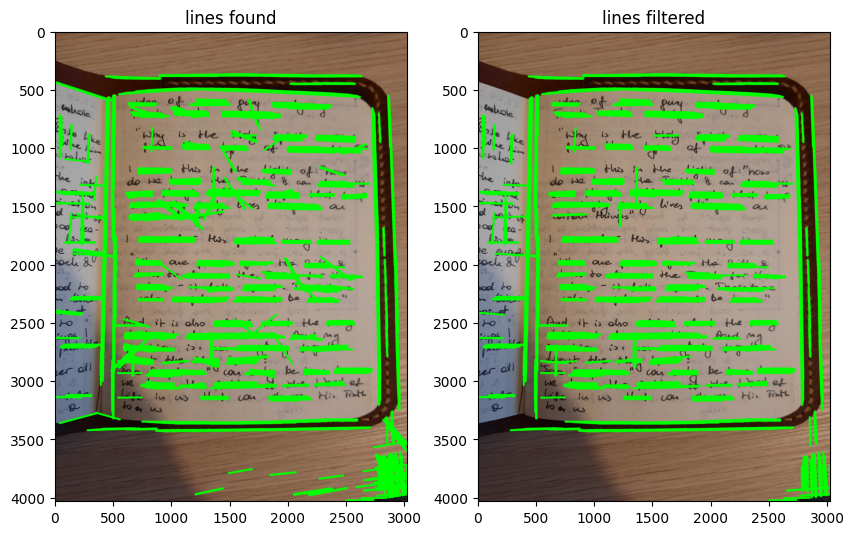

In [13]:
# Apply the Probabilistic Hough Line Transform
lines = cv2.HoughLinesP(
    dilated,              # Edge-detected image
    rho=1,                # Distance resolution in pixels
    theta=np.pi / 180,    # Angle resolution in radians
    threshold=100,        # Minimum number of intersections to detect a line
    minLineLength=200,    # Minimum length of line to be detected
    maxLineGap=30         # Maximum allowed gap between line segments to be connected
)

# Filter lines to only have horizontal & vertical
horizontal_angle_variance = 5
vertical_angle_variance = 5
horizontal_lines, vertical_lines = filter_lines2(lines, horizontal_angle_variance, vertical_angle_variance)
filtered_lines = horizontal_lines + vertical_lines

if show_images:
    plt.figure(figsize=figsize)
    plt.subplot(1, 2, 1)
    draw_lines(img, lines, title="lines found")
    
    plt.subplot(1, 2, 2)
    draw_lines(img, filtered_lines, title="lines filtered")
    
    plt.show()

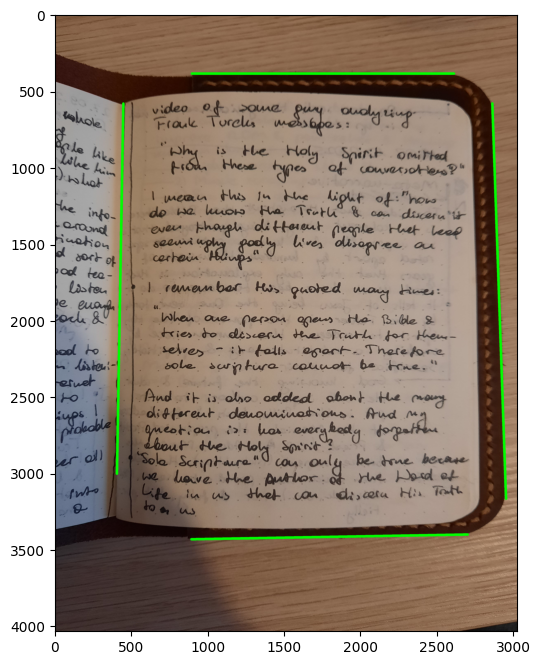

In [14]:
edges_horizontal = select_edge_lines(horizontal_lines, "horizontal", min_separation=2500)
edges_vertical = select_edge_lines(vertical_lines, "vertical", min_separation=2000)

if show_images:
    plt.figure(figsize=figsize)
    draw_lines(img, edges_horizontal+edges_vertical)
    plt.show()

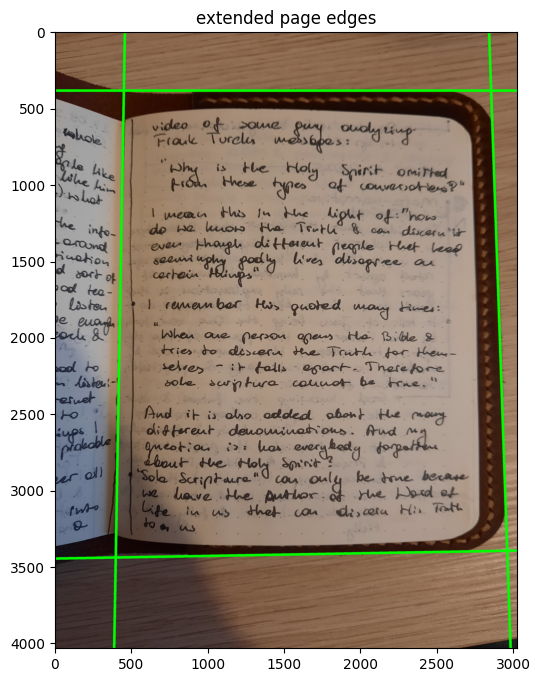

In [15]:
extended_horizontal_edges = [extend_line_to_image(l, img.shape, "horizontal") for l in edges_horizontal]
extended_vertical_edges = [extend_line_to_image(l, img.shape, "vertical") for l in edges_vertical]

if show_images:
    plt.figure(figsize=figsize)
    draw_lines(img, extended_horizontal_edges+extended_vertical_edges, title="extended page edges")
    plt.show

[(450, 383), (2855, 383), (2959, 3395), (397, 3439)]


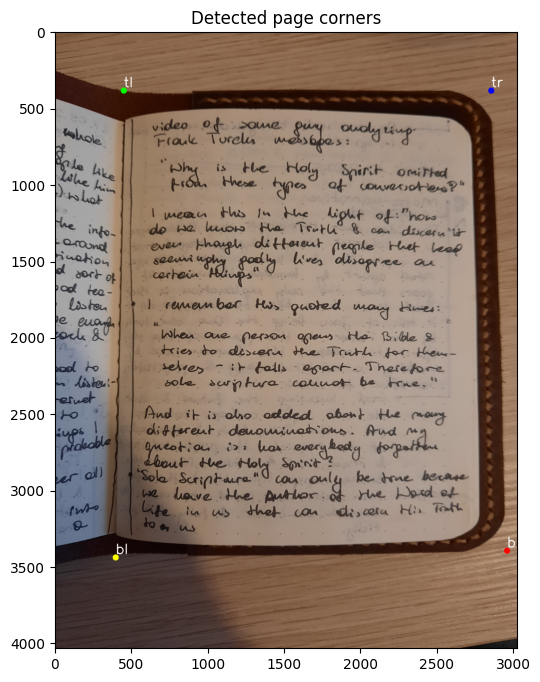

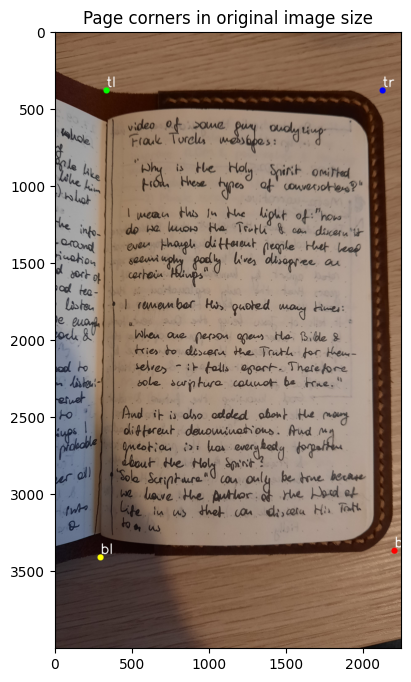

In [16]:
top_line, bottom_line = edges_horizontal
left_line, right_line = edges_vertical

tl = compute_intersection(top_line, left_line)    # top-left
tr = compute_intersection(top_line, right_line)   # top-right
bl = compute_intersection(bottom_line, left_line) # bottom-left
br = compute_intersection(bottom_line, right_line)# bottom-right

corners = [tl, tr, br, bl]
for x, y in corners:
    if x < 0 or y < 0:
        print(x, y)

corners = [clip_point_to_image(cnr, img.shape) for cnr in corners]
print(corners)

if show_images:
    plt.figure(figsize=figsize)
    draw_corners(img, corners, "Detected page corners")
    plt.show()

if resize_image:
    corners_original = rescale_corners_to_original(corners, scale_x, scale_y)
    if show_images:
        plt.figure(figsize=figsize)
        draw_corners(img_original, corners_original, "Page corners in original image size")
        plt.show()

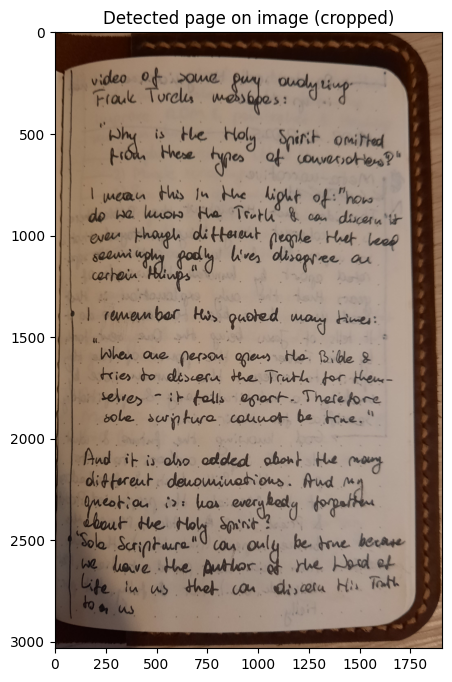

In [17]:
plt.figure(figsize=figsize)
if resize_image:
    crop_from_corners(img_original, corners_original, "Detected page on image (cropped)")
else:
    crop_from_corners(img_original, corners, "Detected page on image (cropped)")
plt.show()